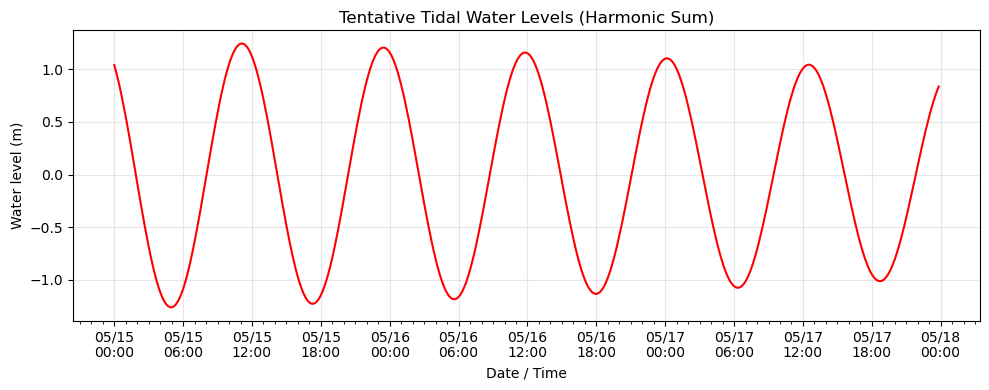

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1) Build a time axis for 3 days at 10‑minute intervals
#    Note: use a normal minus sign "-"
t = pd.date_range("2025-05-15", periods=3*24*6, freq="10min")

# convert to hours from start
hours = (t - t[0]).total_seconds() / 3600

# 2) Define two tidal constituents: M2 (~12.42h) and S2 (12h)
amp_M2, per_M2, phase_M2 = 1.0, 12.42, 0.5
amp_S2, per_S2, phase_S2 = 0.3, 12.00, 1.0

# 3) Build the tidal curve
tidal = ( amp_M2 * np.cos(2*np.pi*hours/per_M2 + phase_M2)
        + amp_S2 * np.cos(2*np.pi*hours/per_S2 + phase_S2) )

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, tidal, color="red", lw=1.5)
ax.set_title("Tentative Tidal Water Levels (Harmonic Sum)")
ax.set_ylabel("Water level (m)")
ax.set_xlabel("Date / Time")
ax.grid(True, alpha=0.3)

# format x-axis nicely
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0,24,6)))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0,24,1)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d\n%H:%M"))

plt.tight_layout()
plt.show()
